In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
#preprocessing
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target

train, valid, test = np.split(
    df.sample(frac=1, random_state=42),
    [int(0.6 * len(df)), int(0.8 * len(df))]
)

def scaling(dataframe, oversample=False):
    if isinstance(dataframe, pd.DataFrame):
        x = dataframe[dataframe.columns[:-1]].values
        y = dataframe[dataframe.columns[-1]].values
    else:
        x = dataframe[:, :-1]
        y = dataframe[:, -1]

    scaler = StandardScaler()
    X = scaler.fit_transform(x)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))
    return data, X, y.astype(int)

train_data, X_train, y_train = scaling(train, oversample=True)
valid_data, X_valid, y_valid = scaling(valid, oversample=False)
test_data,  X_test,  y_test  = scaling(test,  oversample=False)

In [4]:
#KNN
class KNN:
    def __init__(self, k):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y).flatten().astype(int)

    def euclidean_distance(self, p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))

    def predict_one(self, test_point):                         
        distances = [self.euclidean_distance(test_point, train_point)
                     for train_point in self.X_train]
        k_nearest_neighbors = np.argsort(distances)[:self.k]
        k_nearest_labels    = [self.y_train[i] for i in k_nearest_neighbors]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X_test):
        X_test = np.array(X_test)
        return np.array([self.predict_one(point) for point in X_test])

    def score(self, X_test, y_test):                          
        preds = self.predict(X_test)
        return np.mean(preds == y_test)

Single prediction → Predicted: versicolor  |  Actual: versicolor
Validation Accuracy: 0.7333
Test Accuracy:       0.7667

K vs Accuracy:
  k= 1  →  0.8667
  k= 3  →  0.8667
  k= 5  →  0.7333
  k= 7  →  0.8000
  k= 9  →  0.7667
  k=11  →  0.8000

Best k = 1  →  accuracy = 0.8667


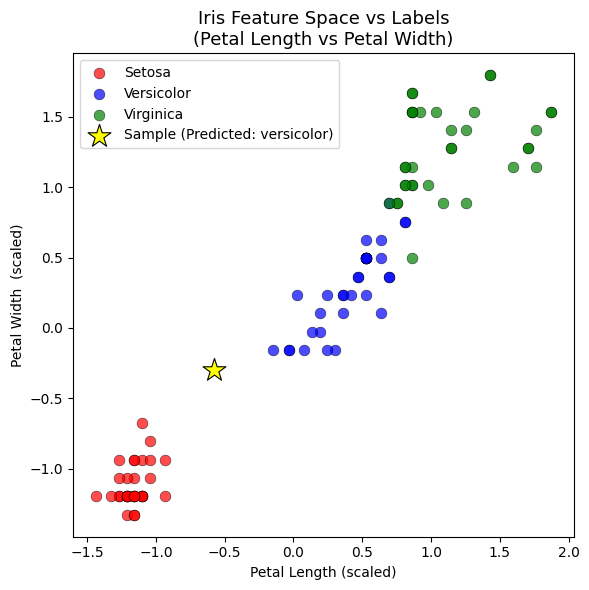

In [5]:
knn = KNN(k=5)
knn.fit(X_train, y_train)

#prediction
sample_point = X_valid[0]
prediction   = knn.predict_one(sample_point)                  
actual       = y_valid[0]
print(f"Single prediction → Predicted: {iris.target_names[prediction]}"
      f"  |  Actual: {iris.target_names[actual]}")

#accuracy
val_acc  = knn.score(X_valid, y_valid)                         
test_acc = knn.score(X_test,  y_test)                          
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

#K sweep
k_values   = [1, 3, 5, 7, 9, 11]
accuracies = []

print("\nK vs Accuracy:")
for k in k_values:
    knn_k = KNN(k=k)
    knn_k.fit(X_train, y_train)
    acc = knn_k.score(X_valid, y_valid)                        
    accuracies.append(acc)
    print(f"  k={k:2d}  →  {acc:.4f}")

best_k   = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest k = {best_k}  →  accuracy = {best_acc:.4f}")

#plot
plt.figure(figsize=(6, 6))

colors     = {0: "red",     1: "blue",       2: "green"}
label_name = {0: "Setosa",  1: "Versicolor", 2: "Virginica"}

for class_id in [0, 1, 2]:
    mask = y_train == class_id
    plt.scatter(
        X_train[mask, 2],
        X_train[mask, 3],
        c=colors[class_id],
        label=label_name[class_id],
        alpha=0.7, s=60,
        edgecolors="k", linewidths=0.4
    )

plt.scatter(
    sample_point[2],
    sample_point[3],
    c="yellow",
    marker="*",
    s=300,
    edgecolors="k",
    linewidths=0.8,
    label=f"Sample (Predicted: {iris.target_names[prediction]})",
    zorder=5
)

plt.title("Iris Feature Space vs Labels\n(Petal Length vs Petal Width)", fontsize=13)
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width  (scaled)")
plt.legend()
plt.tight_layout()
plt.show()

Single prediction → Predicted: versicolor  |  Actual: versicolor
Validation Accuracy: 0.7333
Test Accuracy:       0.7667

K vs Accuracy:
  k= 1  →  0.8667
  k= 3  →  0.8667
  k= 5  →  0.7333
  k= 7  →  0.8000
  k= 9  →  0.7667
  k=11  →  0.8000

Best k = 1  →  accuracy = 0.8667


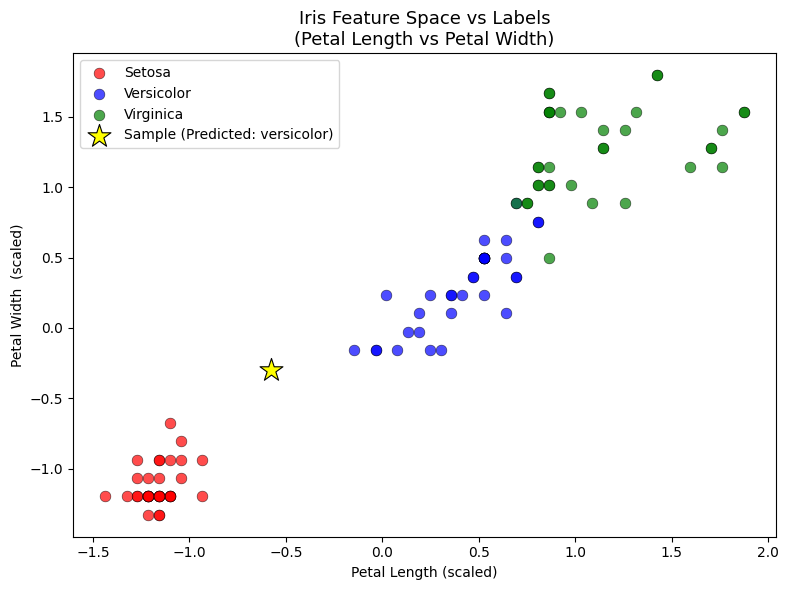

In [6]:
#procedural approach

def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def knn_predict_one(test_point, X_train, y_train, k):
    distances = [euclidean_distance(test_point, train_point)
                 for train_point in X_train]
    k_nearest_indices = np.argsort(distances)[:k]
    k_nearest_labels  = [y_train[i] for i in k_nearest_indices]
    return Counter(k_nearest_labels).most_common(1)[0][0]

def knn_predict(X_test, X_train, y_train, k):
    X_test = np.array(X_test)
    return np.array([knn_predict_one(point, X_train, y_train, k)
                     for point in X_test])

def knn_score(X_test, y_test, X_train, y_train, k):
    preds = knn_predict(X_test, X_train, y_train, k)
    return np.mean(preds == y_test)


#prediction
sample_point = X_valid[0]
prediction   = knn_predict_one(sample_point, X_train, y_train, k=5)
actual       = y_valid[0]
print(f"Single prediction → Predicted: {iris.target_names[prediction]}"
      f"  |  Actual: {iris.target_names[actual]}")

#accuracy
val_acc  = knn_score(X_valid, y_valid, X_train, y_train, k=5)
test_acc = knn_score(X_test,  y_test,  X_train, y_train, k=5)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

k_values   = [1, 3, 5, 7, 9, 11]
accuracies = []

print("\nK vs Accuracy:")
for k in k_values:
    acc = knn_score(X_valid, y_valid, X_train, y_train, k)
    accuracies.append(acc)
    print(f"  k={k:2d}  →  {acc:.4f}")

best_k   = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest k = {best_k}  →  accuracy = {best_acc:.4f}")


def plot_feature_space(X_train, y_train, sample_point, prediction, target_names):
    colors     = {0: "red",    1: "blue",      2: "green"}
    label_name = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

    plt.figure(figsize=(8, 6))

    for class_id in [0, 1, 2]:
        mask = y_train == class_id
        plt.scatter(
            X_train[mask, 2],
            X_train[mask, 3],
            c=colors[class_id],
            label=label_name[class_id],
            alpha=0.7, s=60,
            edgecolors="k", linewidths=0.4
        )

    plt.scatter(
        sample_point[2],
        sample_point[3],
        c="yellow",
        marker="*",
        s=300,
        edgecolors="k",
        linewidths=0.8,
        label=f"Sample (Predicted: {target_names[prediction]})",
        zorder=5
    )

    plt.title("Iris Feature Space vs Labels\n(Petal Length vs Petal Width)", fontsize=13)
    plt.xlabel("Petal Length (scaled)")
    plt.ylabel("Petal Width  (scaled)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_feature_space(X_train, y_train, sample_point, prediction, iris.target_names)